# Машинное обучение, ФКН ВШЭ

# Практическое задание 11. Несбалансированные задачи

## Общая информация
Дата выдачи: 24.04.2025

Мягкий дедлайн: 13.05.2025 23:59 MSK

Жесткий дедлайн: 18.05.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-xx-Username.ipynb

Username — ваша фамилия и имя на латинице именно в таком порядке

## О задании

В этом задании мы разберем основные техники работы в задачах, где один из классов занимает существенно меньшую долю выборки, чем остальные. Для простоты мы обойдемся бинарной задачей, тем не менее, во многом данные методы можно перенести и на задачи с б**о**льшим числом классов. Кроме того, вы получите очередной бесценный опыт исследования случайной библиотеки случайных индусов с нуля.

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

**Задание -1 (1 балл)**. EDA

В качестве данных для нашей работы возьмем выложенный на kaggle датасет транзакций, в котором нужно выискивать мошеннические проводки: [клик](https://www.kaggle.com/mlg-ulb/creditcardfraud). Данная задача по определению подходит под несбалансированную, что можно сказать даже без наличия каких-либо данных (понятно, что среди всех транзакций клиентов очень малая часть будет мошеннической).

Загрузим данные, проведем некоторые классические манипуляции.

In [2]:
!pip install kagglehub[pandas-datasets] --quiet

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "creditcard.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "mlg-ulb/creditcardfraud",
    file_path
)

In [3]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Наши данные были анонимизированы. Мы имеем 30 признаков, из которых 28 - это результаты PCA-преобразования на исходном датасете. Еще 2 признака представляют собой время в секундах, прошедшее с момента первой транзакции в датасете, и размер транзакции. Скажите, какова доля положительных объектов в выборке?

In [4]:
df.Class.value_counts(normalize = True)

,proportion
Class,
0,0.998273
1,0.001727


Крайне мала доля(((

Начнем с обработки времени. Секунды сами по себе не несут большой информации о зависимостях в данных, попробуйте по ним создать признаки "час" (от 0 до 23) и "день" (от 0 до ...) в аналогичной манере (принимая первый объект выборки за начальную точку). Сколько дней покрывают данные?

In [5]:
h = 60*60
d = 24*60*60
df['Days'] = df.Time//d
df['Hours'] = (df.Time%d)//h

In [6]:
df['Days'].value_counts()

,count
Days,
0.0,144786
1.0,140021


Данные покрывают информацию о сделках за 2 дня.

Постройте следующие графики:

1. Распределение числа транзакций по каждому часу (line-plot).
2. Распределение доли мошеннических транзакций по каждому часу (line-plot)
3. То же самое для дней (здесь можно использовать bar-plot, так как дней должно быть немного).

Какие выводы можно сделать из графиков? На ваш взгляд, как можно связать полученные нами часы с реальными часами в сутках?

In [7]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Days,Hours
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0


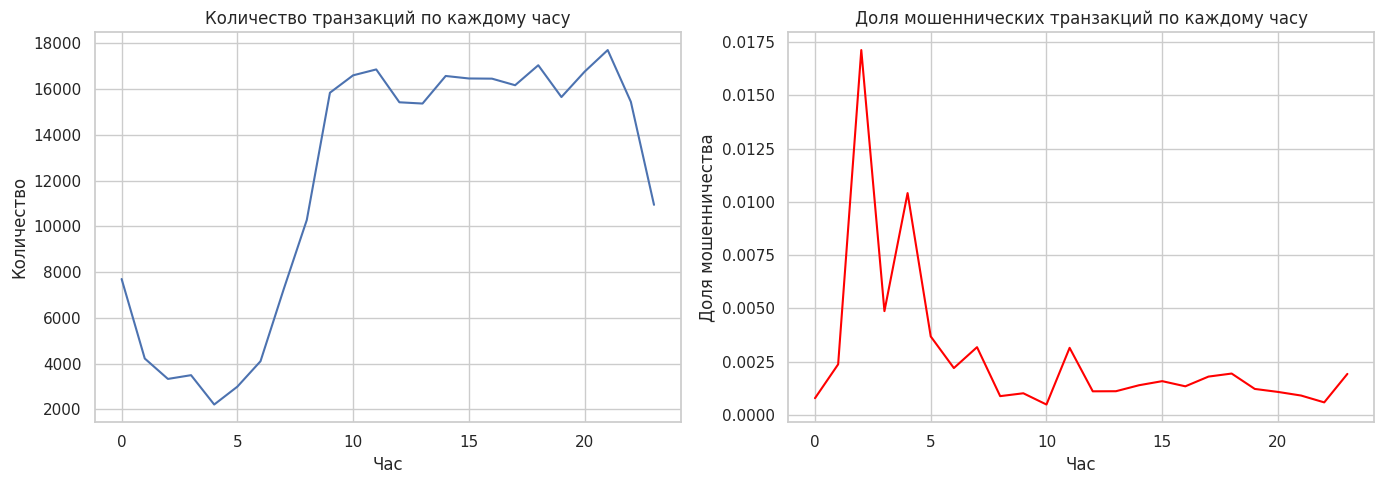

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df.groupby('Hours')['Class'].count().plot(kind='line')
plt.title('Количество транзакций по каждому часу')
plt.xlabel('Час')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
df.groupby('Hours')['Class'].value_counts(normalize=True).unstack()[1].plot(kind='line', color='red')
plt.title('Доля мошеннических транзакций по каждому часу')
plt.xlabel('Час')
plt.ylabel('Доля мошенничества')
plt.grid(True)

plt.tight_layout()
plt.show()

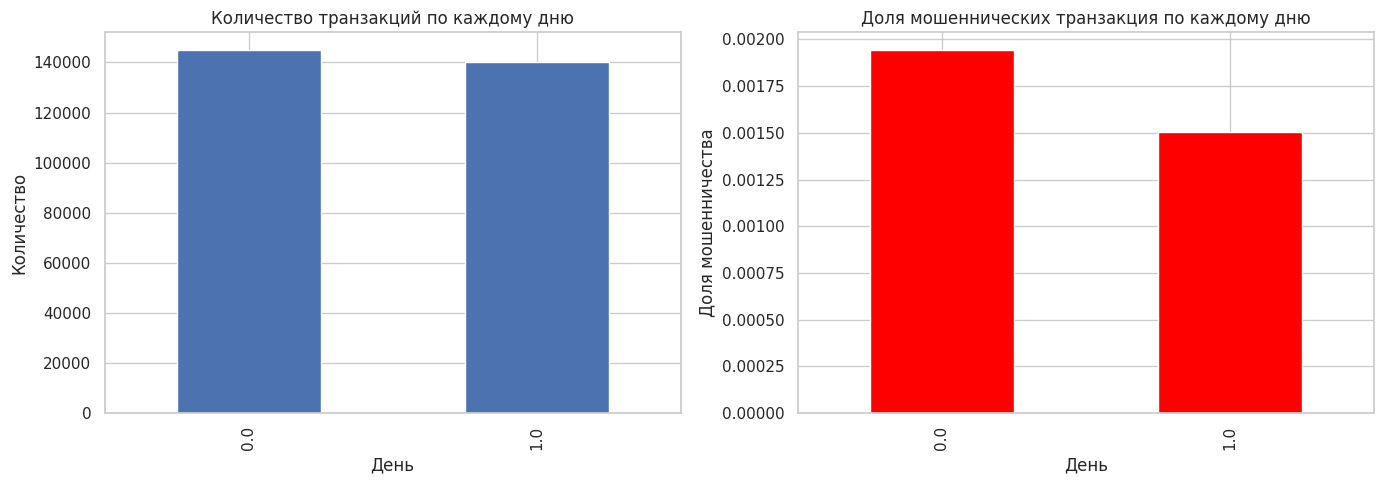

In [9]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
df.groupby('Days')['Class'].count().plot(kind = 'bar');
plt.title('Количество транзакций по каждому дню')
plt.xlabel('День')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
df.groupby('Days')['Class'].value_counts(normalize = True).unstack()[1].plot(kind = 'bar', color = 'red');
plt.title('Доля мошеннических транзакция по каждому дню');
plt.xlabel('День')
plt.ylabel('Доля мошенничества');

plt.tight_layout()
plt.show()

С анонимизированными признаками вряд ли можно придумать что-то интересное. Попробуйте (например, с помощью корреляции?) выбрать несколько наиболее важных признаков и поглядеть на различия в их распределении для разных классов.

In [10]:
correlations = np.abs(df.corr(numeric_only=True)["Class"].drop("Class")).sort_values(ascending=False)
print(correlations.head(10))

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


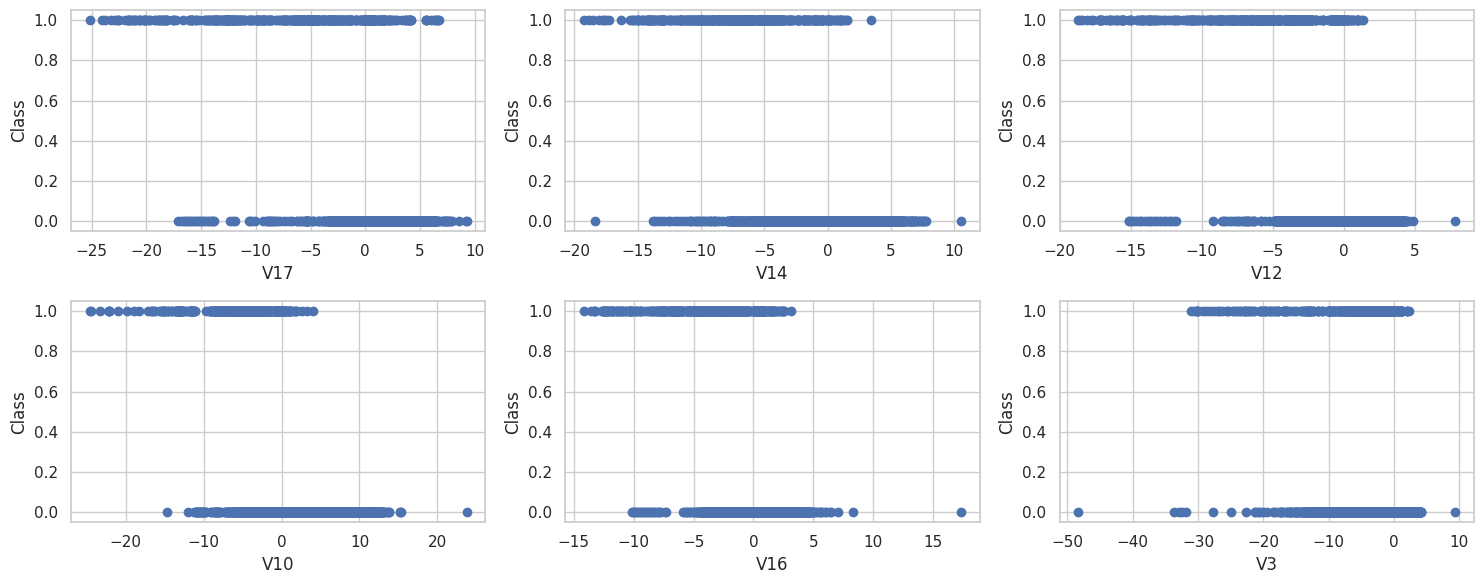

In [11]:
import matplotlib.pyplot as plt

cols = list(correlations[:6].index)

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
axes = axes.ravel()

for i, col in enumerate(cols):
    axes[i].scatter(df[col], df['Class'])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Class')

plt.tight_layout()
plt.show()

Теперь давайте разделим данные. Отделите хронологически последние 20% транзакций и поделите их пополам (также хронологически, т.е. без перемешивания) на валидационные и тестовые. Это разбиение не совсем корректно (как можно было заметить, мошеннические транзакции имеют разное распределение во времени - по-хорошему, нам стоило бы выделить целые сутки записей как под валидацию, так и под тест), тем не менее, мы не сможем получить больше данных для адекватного контроля, поэтому обойдемся этим.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(df.drop('Class', axis=1), df['Class'], test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Часть 1. Несбалансированная классификация.

**Задание 0. (1 балл)**: перед началом работы давайте поговорим о том, как мы будем оценивать качество. Классические метрики для качества классификации чаще всего "ломаются" на задачах с сильным перекосом. Чему будет равно значение accuracy для наивного предсказания (= мажорный класс для каждого объекта)? (можете не отвечать, просто подумайте)

Из курса МО-1 вам уже известно, что мы можем использовать в таких задачах `AUC-PR` и получать адекватные показатели. Можно сказать, что `AUC-PR` представляет собой матожидание `precision` по распределению, заданному выигрышем в `recall` при смене порога.

In [13]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score, accuracy_score, classification_report

def aucpr(y_true, y_scores):
  precision, recall, _ = precision_recall_curve(y_true, y_scores)
  return auc(recall, precision)

def avgpr(y_true, y_scores):
  precision, recall, _ = precision_recall_curve(y_true, y_scores)
  return np.sum((recall[1:] - recall[:-1]) * precision[1:])

Тем не менее, существуют и другие, не менее интересные метрики. Одной из таких метрик является коэффициент Каппа Коэна, представляющий собой нормализованную `accuracy`:

$$\kappa = \frac{p_o - p_e}{1 - p_e}$$

Данная метрика служит в качестве меры согласованности между двумя независимыми предсказателями, но ничего не знает про "верные" и "предсказанные" метки (в отличие от многих других метрик машинного обучения). Здесь $p_o$ - доля согласованных предсказаний, а $p_e$ - доля согласованных предсказаний, которая могла бы получиться при случайных ответах предсказателей. В нашем случае это работает так:

• В качестве $p_o$ берем accuracy

• В качестве $p_e$ примем следующую величину - вероятность случайного соглашения позитивных ответов (произведение долей позитивных ответов в обоих предсказаниях) плюс вероятность случайного соглашения негативных ответов (произведение долей негативных ответов в обоих предсказаниях)

Метрика принимает значения от -1 до 1, где 1 - полная согласованность, 0 - согласованность на уровне рандома, -1 - совсем плохо. Как уже говорилось, метрика не различает "верные" и "предсказанные" метки, поэтому является симметричной (можете использовать это для отладки):

In [14]:
# y_true = np.array([0, 0, 1, 1, 1, 0, 1])
# y_pred = np.array([0, 1, 1, 1, 0, 0, 1])

In [15]:
from sklearn.metrics import cohen_kappa_score # насколько модель лучше случайного угадывания
def cks(y_true, y_pred):
  p0 = accuracy_score(y_true, y_pred)

  unique_classes = np.unique(np.concatenate([y_true, y_pred])) # уникальные классы, которые встречаются хотя бы где-то
  p_true = np.array([np.mean(y_true == c) for c in unique_classes]) #подсчитать долю каждого уникального класса
  p_pred = np.array([np.mean(y_pred == c) for c in unique_classes])
  pe = np.sum(p_true * p_pred)
  return (p0 - pe) / (1 - pe)

Еще одной метрикой в такой задаче служит коэффициент корреляции Мэтьюза, выражающийся в терминах матрицы ошибок следующим образом:

$$\text{MCC} = \frac{TP\times TN - FP \times FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

Метрика принимает значения от -1 до 1, интерпретируемые аналогичным образом.

In [16]:
from sklearn.metrics import matthews_corrcoef

def mcc(y_true, y_pred):
  tp = np.sum((y_true == 1)&(y_pred == 1))
  tn = np.sum((y_true == 0)&(y_pred == 0))
  fp = np.sum((y_true == 0)&(y_pred == 1))
  fn = np.sum((y_true == 1)&(y_pred == 0))
  # return tp, tn, fp, fn
  return (tp*tn - fp*fn)/np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))

Обратите внимание, что эти метрики вычисляются на бинаризованных предсказаниях, поэтому может иметь смысл дополнительная настройка порога бинаризации.

Давайте проверим, что наши метрики действительно подходят под задачу. Вычислите их значения для наивного предсказания (aka мажорный класс для всех объектов):

In [17]:
def print_stats(y_true, y_scores, t = 0.5):
    y_pred = (y_scores >= t).astype(int)

    print(f'AUC PR (average_precision_score): {average_precision_score(y_true, y_scores):.4f}')
    print(f'AUC PR (auc from PR curve):        {aucpr(y_true, y_scores):.4f}')

    # Метрики по меткам
    print(f'Kappa Score:                        {cks(y_true, y_pred):.4f}')
    print(f'MCC:                                {mcc(y_true, y_pred):.4f}')

In [18]:
y_test_pred = np.zeros(y_test.shape)
print_stats(y_test, y_test_pred)

AUC PR (average_precision_score): 0.0008
AUC PR (auc from PR curve):        0.5004
Kappa Score:                        0.0000
MCC:                                nan


Давайте запустим бейзлайн-решение для нашей задачи. С чего же начнем? Возьмите `catboost` и обучите его классификатор на наших данных (используйте все признаки). Вычислите значения всех метрик на тестовой части, для контроля переобучения используйте валидационную (здесь и далее везде, где фигурирует `catboost`).

In [19]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 11.6 MB/s eta 0:00:00


In [20]:
from catboost import CatBoostClassifier
model = CatBoostClassifier(verbose = 50, iterations = 250)
model.fit(X_train, y_train, eval_set=(X_val, y_val))
y_test_pred_cb = model.predict_proba(X_test)[:,1]

Learning rate set to 0.221382
0:	learn: 0.1719767	test: 0.1678895	best: 0.1678895 (0)	total: 139ms	remaining: 34.6s
50:	learn: 0.0014841	test: 0.0029686	best: 0.0029107 (47)	total: 4.11s	remaining: 16.1s
100:	learn: 0.0010552	test: 0.0030293	best: 0.0028814 (63)	total: 9.48s	remaining: 14s
150:	learn: 0.0007841	test: 0.0029880	best: 0.0028814 (63)	total: 15.5s	remaining: 10.2s
200:	learn: 0.0005434	test: 0.0030157	best: 0.0028814 (63)	total: 20.7s	remaining: 5.04s
249:	learn: 0.0003532	test: 0.0030843	best: 0.0028814 (63)	total: 24.1s	remaining: 0us

bestTest = 0.002881417347
bestIteration = 63

Shrink model to first 64 iterations.


In [19]:
print_stats(y_test,y_test_pred_cb)

AUC PR (average_precision_score): 0.6954
AUC PR (auc from PR curve):        0.6938
Kappa Score:                        0.7367
MCC:                                0.7460


Если вы все сделали правильно, у вас должны были получиться значения в районе 0.7.

**Задание 1. (1 балл)**. Многие реализации методов предлагают встроенные способы для борьбы с нашей проблемой. Самое часто встречающееся решение - просто добавить вес в функции потерь для минорного класса (таким образом, ошибка на объекте минорного класса будет весить больше, чем для мажорного). В `catboost` это также реализовано, причем для бинарной задачи это можно сделать целыми двумя способами (можете выбрать любой, на свой вкус, автор задания предпочитает отдельный скейлинг для минорного класса). Чаще всего в качестве веса берется отношение числа объектов мажорного класса к числу минорного. Попробуйте обучить модель с таким скалированием и сравните метрики на тестовой части с бейзлайном.

In [20]:
from catboost import CatBoostClassifier

sample_weight = np.where(y_train == 0, 1,  y_train.value_counts()[0]/y_train.value_counts()[1])

model = CatBoostClassifier(verbose = 50, iterations = 250)

model.fit(X_train, y_train, eval_set=(X_val, y_val), sample_weight=sample_weight)
y_test_pred_cb = model.predict_proba(X_test)[:,1]

Learning rate set to 0.221382
0:	learn: 0.3827284	test: 0.4622336	best: 0.4622336 (0)	total: 162ms	remaining: 40.3s
50:	learn: 0.0061344	test: 0.0055346	best: 0.0055346 (50)	total: 10.2s	remaining: 39.7s
100:	learn: 0.0013025	test: 0.0034641	best: 0.0034603 (98)	total: 23.5s	remaining: 34.6s
150:	learn: 0.0011863	test: 0.0034313	best: 0.0034172 (111)	total: 35.8s	remaining: 23.5s
200:	learn: 0.0010701	test: 0.0034064	best: 0.0033934 (190)	total: 42.5s	remaining: 10.4s
249:	learn: 0.0010695	test: 0.0034059	best: 0.0033934 (190)	total: 45.3s	remaining: 0us

bestTest = 0.003393373751
bestIteration = 190

Shrink model to first 191 iterations.


In [22]:
print_stats(y_test,y_test_pred_cb)

AUC PR (average_precision_score): 0.7188
AUC PR (auc from PR curve):        0.7179
Kappa Score:                        0.6271
MCC:                                0.6331


Выше сделала ручную нормировку на количество объектов

In [ ]:
weights = [1, y_train.value_counts()[0]/y_train.value_counts()[1]]

model = CatBoostClassifier(verbose = 50, iterations = 250, class_weights=weights)
model.fit(X_train, y_train, eval_set=(X_val, y_val))
y_test_pred_cb = model.predict_proba(X_test)[:,1]

Learning rate set to 0.221382
0:	learn: 0.3827284	test: 0.4736358	best: 0.4736358 (0)	total: 77.4ms	remaining: 19.3s
50:	learn: 0.0061344	test: 0.4411337	best: 0.1976513 (5)	total: 6.92s	remaining: 27s
100:	learn: 0.0013025	test: 0.6293195	best: 0.1976513 (5)	total: 10.3s	remaining: 15.2s
150:	learn: 0.0011863	test: 0.6408540	best: 0.1976513 (5)	total: 13.4s	remaining: 8.76s
200:	learn: 0.0010701	test: 0.6544033	best: 0.1976513 (5)	total: 20.7s	remaining: 5.05s
249:	learn: 0.0010695	test: 0.6545694	best: 0.1976513 (5)	total: 29.3s	remaining: 0us

bestTest = 0.1976512799
bestIteration = 5

Shrink model to first 6 iterations.


In [ ]:
print_stats(y_test,y_test_pred_cb)

AUC PR (average_precision_score): 0.6281
AUC PR (auc from PR curve):        0.6242
Kappa Score:                        0.0839
MCC:                                0.1848


Здесь все сломалось да(((

Поскольку данный вес будет являться гиперпараметром метода, было бы опрометчиво остановиться на одном значении (тем более, с большой вероятностью у вас все сломалось). Запустите перебор для этого гиперпараметра на валидационной выборке (используйте `PR-AUC`), подберите оптимальный порог бинаризации для $\kappa$ или $\text{MCC}$. Для лучшего найденного веса и порога вычислите все метрики на тестовой части.

При этом можете также проверить отдельное скалирование в большую сторону для мажорного класса (т.е. веса минорного сделать меньше 1) и экстремальные скалирования (т.е. веса минорного больше, чем в начале этого задания). Какой вес получился оптимальным?

In [24]:
# !pip install optuna
# не пригодилось пока

In [ ]:
weights_to_try = [5, 25, 50, 100, 150, 300]
val_results = []

for w in weights_to_try:
    class_weights = [1, w]
    model = CatBoostClassifier(
        verbose=50,
        iterations=250,
        class_weights=class_weights,
        random_seed=42
    )
    model.fit(X_train, y_train, eval_set=(X_val, y_val))
    y_val_proba = model.predict_proba(X_val)[:, 1]
    ap = average_precision_score(y_val, y_val_proba)
    val_results.append((w, ap))
    print(f"Вес: {w}, AUC-PR на валидации: {ap:.4f}")
    print()
best_weight, best_ap = max(val_results, key=lambda x: x[1])
print(f"Лучший вес: {best_weight}, AUC-PR на валидации: {best_ap:.4f}")

Learning rate set to 0.221382
0:	learn: 0.1946281	test: 0.1878739	best: 0.1878739 (0)	total: 179ms	remaining: 44.5s
50:	learn: 0.0032544	test: 0.0113317	best: 0.0111522 (13)	total: 10.2s	remaining: 39.8s
100:	learn: 0.0010705	test: 0.0124464	best: 0.0111522 (13)	total: 20.3s	remaining: 29.9s
150:	learn: 0.0004347	test: 0.0136113	best: 0.0111522 (13)	total: 25.1s	remaining: 16.5s
200:	learn: 0.0002448	test: 0.0148089	best: 0.0111522 (13)	total: 30s	remaining: 7.32s
249:	learn: 0.0001532	test: 0.0156852	best: 0.0111522 (13)	total: 33.3s	remaining: 0us

bestTest = 0.01115219595
bestIteration = 13

Shrink model to first 14 iterations.
Вес: 5, AUC-PR на валидации: 0.8326

Learning rate set to 0.221382
0:	learn: 0.2593894	test: 0.2535763	best: 0.2535763 (0)	total: 70.7ms	remaining: 17.6s
50:	learn: 0.0057599	test: 0.0513133	best: 0.0383758 (31)	total: 3.54s	remaining: 13.8s
100:	learn: 0.0013606	test: 0.0604790	best: 0.0383758 (31)	total: 8.95s	remaining: 13.2s
150:	learn: 0.0006179	test: 0.

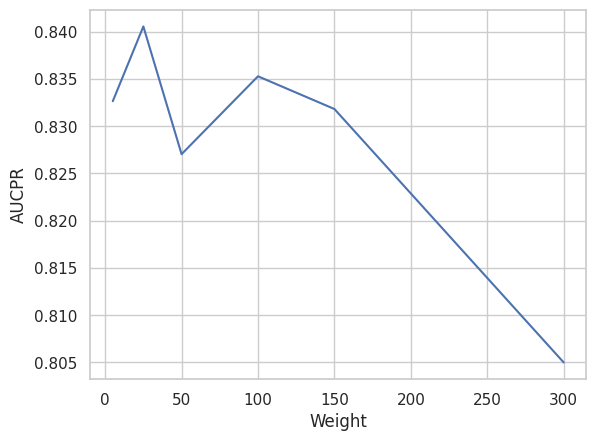

In [ ]:
max(val_results, key = lambda x:x[1])
weights, scores = zip(*val_results)

plt.plot(list(weights), list(scores))
plt.xlabel('Weight')
plt.ylabel('AUCPR')
plt.show()

Теперь подбираем порог

In [ ]:
tresholds_to_try = np.arange(0.5, 1, 0.05)
cks_results = []
model = CatBoostClassifier(verbose = 50, iterations = 250, class_weights = [1, best_weight])
model.fit(X_train, y_train, eval_set=(X_val, y_val))
y_val_pred = model.predict_proba(X_val)[:,1]

for t in tresholds_to_try:
    y_pred = (y_val_pred > t).astype('int')
    kappa = cks(y_val, y_pred)
    cks_results.append((t, kappa))
    print(f"T: {t}, Kappa Score: {kappa:.4f}")
    print()
best_t, best_cks = max(cks_results, key=lambda x: x[1])
print(f"Лучший порог: {best_t}, Kappa Score: {best_cks}")

Learning rate set to 0.221382
0:	learn: 0.2822560	test: 0.2901845	best: 0.2901845 (0)	total: 78.3ms	remaining: 19.5s
50:	learn: 0.0050227	test: 0.0399569	best: 0.0317485 (20)	total: 3.56s	remaining: 13.9s
100:	learn: 0.0013906	test: 0.0481052	best: 0.0317485 (20)	total: 8.44s	remaining: 12.4s
150:	learn: 0.0005933	test: 0.0567707	best: 0.0317485 (20)	total: 11.7s	remaining: 7.7s
200:	learn: 0.0003320	test: 0.0603766	best: 0.0317485 (20)	total: 15s	remaining: 3.66s
249:	learn: 0.0003318	test: 0.0603770	best: 0.0317485 (20)	total: 19.3s	remaining: 0us

bestTest = 0.03174849079
bestIteration = 20

Shrink model to first 21 iterations.
T: 0.5, Kappa Score: 0.7886

T: 0.55, Kappa Score: 0.8034

T: 0.6000000000000001, Kappa Score: 0.8152

T: 0.6500000000000001, Kappa Score: 0.8314

T: 0.7000000000000002, Kappa Score: 0.8197

T: 0.7500000000000002, Kappa Score: 0.8280

T: 0.8000000000000003, Kappa Score: 0.8280

T: 0.8500000000000003, Kappa Score: 0.8160

T: 0.9000000000000004, Kappa Score: 0.

In [ ]:
y_test_pred = model.predict_proba(X_test)[:,1]
print_stats(y_test, y_test_pred, t = best_t)

AUC PR (average_precision_score): 0.6841
AUC PR (auc from PR curve):        0.6829
Kappa Score:                        0.7178
MCC:                                0.7237


**Задание 2. (1 балл)**. На самом деле, то, что мы сейчас делали, очень схоже с другой распространенной техникой - оверсэмплингом. Фактически, мы можем продублировать все объекты минорного класса и получить тот же эффект, какой был бы при использовании веса, равного 2. Тем не менее, такой подход - это лишь малая часть того, что мы можем проделать с целью повысить число объектов минорного класса.

Для продолжения работы установим библиотеку [imbalanced-learn](https://imbalanced-learn.org/stable/):

In [25]:
!pip3 install imbalanced-learn
# conda install -c conda-forge imbalanced-learn

Первый метод, которым мы воспользуемся, называется SMOTE (его вы уже разбирали на лекции). Кратко напомним суть: мы выбираем случайного кандидата среди $k$ ближайших соседей объекта минорного класса, затем берем точку на отрезке между двумя объектами (т.е. выпуклую комбинацию со случайными коэффициентами) и добавляем в выборку.

In [26]:
from imblearn.over_sampling import SMOTE

Используйте SMOTE для ресэмплинга обучающей выборки, на новой выборке обучите модель (вес положительных объектов скалировать не нужно). Замерьте качество на тестовой выборке (**важно!** не преобразовывайте валидационную и тестовую выборку никак - мы не хотим отслеживать качество на объектах, которых в реальности не существует). Сравните полное выравнивание выборки с частичным (т.е. таким, что баланс классов улучшается, но не достигает равенства - скажем, 1:2 и 1:10).

In [27]:
ratios_to_try = [1, 1/2, 1/10]

for ratio in tqdm(ratios_to_try):
  smote = SMOTE(random_state = 42, sampling_strategy = ratio)
  X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
  model = CatBoostClassifier(verbose = 50, iterations = 250, random_state = 42)
  model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val, y_val))
  y_test_pred = model.predict_proba(X_test)[:,1]

  print(f"Ratio: {ratio}")
  print_stats(y_test, y_test_pred)
  print()

  0%|          | 0/3 [00:00<?, ?it/s]

Learning rate set to 0.262603
0:	learn: 0.2551701	test: 0.3012476	best: 0.3012476 (0)	total: 348ms	remaining: 1m 26s
50:	learn: 0.0074046	test: 0.0080942	best: 0.0080942 (50)	total: 17.2s	remaining: 1m 7s
100:	learn: 0.0023139	test: 0.0046661	best: 0.0046661 (100)	total: 23.5s	remaining: 34.6s
150:	learn: 0.0020890	test: 0.0046075	best: 0.0046074 (145)	total: 30.5s	remaining: 20s
200:	learn: 0.0020616	test: 0.0046124	best: 0.0046074 (145)	total: 36.1s	remaining: 8.8s
249:	learn: 0.0020615	test: 0.0046124	best: 0.0046074 (145)	total: 43.1s	remaining: 0us

bestTest = 0.004607445876
bestIteration = 145

Shrink model to first 146 iterations.
Ratio: 1
AUC PR (average_precision_score): 0.7255
AUC PR (auc from PR curve):        0.7250
Kappa Score:                        0.6528
MCC:                                0.6562

Learning rate set to 0.244591
0:	learn: 0.2915378	test: 0.3173450	best: 0.3173450 (0)	total: 114ms	remaining: 28.3s
50:	learn: 0.0092790	test: 0.0039493	best: 0.0039493 (50)	t

**Бонус (1.5 балла)**. Для vanilla SMOTE существуют некоторые модификации, часть из которых была реализована в библиотеке imblearn. Во время лекций/семинаров эти модификации не рассматривались, тем не менее, мы все равно их исследуем.

Найдите статьи о следующих методах и попробуйте вкратце сформулировать, в чем их основная идея (сделайте так, чтобы человек, знакомый с машинным обучением в целом, но не слышавший конкретно про это смог понять):

BorderlineSMOTE - https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.BorderlineSMOTE.html

SVM-SMOTE - https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SVMSMOTE.html

K-Means-SMOTE - https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.KMeansSMOTE.html

ADASYN - https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.ADASYN.html

Теперь попробуйте сравнить качество всех методов на наших данных.

In [ ]:
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, SVMSMOTE, KMeansSMOTE, ADASYN

**BorderlineSMOTE**

In [ ]:
sm = BorderlineSMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)
model = CatBoostClassifier(verbose = 50, iterations = 250, random_state = 42)
model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val, y_val))
y_test_pred = model.predict_proba(X_test)[:,1]

print_stats(y_test, y_test_pred)

Learning rate set to 0.5
0:	learn: 0.0462812	total: 191ms	remaining: 47.6s
50:	learn: 0.0014650	total: 8.23s	remaining: 32.1s
100:	learn: 0.0014648	total: 14s	remaining: 20.7s
150:	learn: 0.0014648	total: 21.1s	remaining: 13.8s
200:	learn: 0.0014648	total: 30.4s	remaining: 7.42s
249:	learn: 0.0014648	total: 36.4s	remaining: 0us
AUC PR (average_precision_score): 0.6309
AUC PR (auc from PR curve):        0.6207
Kappa Score:                        0.6034
MCC:                                0.6123


**SVMSMOTE**

In [ ]:

sm = SVMSMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)
model = CatBoostClassifier(verbose = 50, iterations = 250, random_state = 42)
model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val, y_val))
y_test_pred = model.predict_proba(X_test)[:,1]

print_stats(y_test, y_test_pred)

Learning rate set to 0.262603
0:	learn: 0.1491481	test: 0.1580811	best: 0.1580811 (0)	total: 153ms	remaining: 38.2s
50:	learn: 0.0015260	test: 0.0028867	best: 0.0028867 (48)	total: 7.54s	remaining: 29.4s
100:	learn: 0.0014377	test: 0.0028807	best: 0.0028616 (55)	total: 13s	remaining: 19.1s
150:	learn: 0.0014377	test: 0.0028807	best: 0.0028616 (55)	total: 19.9s	remaining: 13.1s
200:	learn: 0.0014377	test: 0.0028807	best: 0.0028616 (55)	total: 25.4s	remaining: 6.2s
249:	learn: 0.0014377	test: 0.0028807	best: 0.0028616 (55)	total: 32.3s	remaining: 0us

bestTest = 0.002861631375
bestIteration = 55

Shrink model to first 56 iterations.
AUC PR (average_precision_score): 0.6690
AUC PR (auc from PR curve):        0.6660
Kappa Score:                        0.6397
MCC:                                0.6444


**K-Means-SMOTE**

In [ ]:

sm = KMeansSMOTE(cluster_balance_threshold=0.003, random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)
model = CatBoostClassifier(verbose = 50, iterations = 250, random_state = 42)
model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val, y_val))
y_test_pred = model.predict_proba(X_test)[:,1]

print_stats(y_test, y_test_pred)

Learning rate set to 0.262603
0:	learn: 0.1445992	test: 0.1037229	best: 0.1037229 (0)	total: 312ms	remaining: 1m 17s
50:	learn: 0.0012474	test: 0.0029011	best: 0.0028669 (37)	total: 10.9s	remaining: 42.3s
100:	learn: 0.0012318	test: 0.0028827	best: 0.0028669 (37)	total: 20s	remaining: 29.5s
150:	learn: 0.0012178	test: 0.0028977	best: 0.0028669 (37)	total: 25.5s	remaining: 16.7s
200:	learn: 0.0012169	test: 0.0028969	best: 0.0028669 (37)	total: 33.6s	remaining: 8.18s
249:	learn: 0.0012163	test: 0.0028960	best: 0.0028669 (37)	total: 42.5s	remaining: 0us

bestTest = 0.002866858436
bestIteration = 37

Shrink model to first 38 iterations.
AUC PR (average_precision_score): 0.6136
AUC PR (auc from PR curve):        0.5917
Kappa Score:                        0.7999
MCC:                                0.8039


**ADASYN**

In [ ]:


ada = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)
model = CatBoostClassifier(verbose = 50, iterations = 250, random_state = 42)
model.fit(X_train_resampled, y_train_resampled, eval_set=(X_val, y_val))
y_test_pred = model.predict_proba(X_test)[:,1]

print_stats(y_test, y_test_pred)

Learning rate set to 0.262612
0:	learn: 0.2696348	test: 0.3102340	best: 0.3102340 (0)	total: 153ms	remaining: 38.1s
50:	learn: 0.0074535	test: 0.0044223	best: 0.0044223 (50)	total: 8.09s	remaining: 31.6s
100:	learn: 0.0027622	test: 0.0036137	best: 0.0036136 (97)	total: 14.2s	remaining: 21s
150:	learn: 0.0023700	test: 0.0036235	best: 0.0035981 (147)	total: 21s	remaining: 13.8s
200:	learn: 0.0019979	test: 0.0035897	best: 0.0035740 (172)	total: 26.6s	remaining: 6.5s
249:	learn: 0.0019978	test: 0.0035897	best: 0.0035740 (172)	total: 33.7s	remaining: 0us

bestTest = 0.003573952269
bestIteration = 172

Shrink model to first 173 iterations.
AUC PR (average_precision_score): 0.7087
AUC PR (auc from PR curve):        0.7077
Kappa Score:                        0.6954
MCC:                                0.6961


**Задание 3. (1 балл)**. До этого момента все наши решения концентрировались на работе с минорным классом. Теперь давайте попробуем зайти с другой стороны. Может быть, для восстановления закономерностей нам не нужно столько объектов мажорного класса, и они просто засоряют нам выборку лишней информацией?

Для решения этой проблемы существуют методы андерсэмплинга. Самое простое, что можно придумать - удалять точки мажорного класса, пока мы не получим приемлемый баланс. Протестируйте следующий метод и постройте графики достигаемых значений метрик от баланса классов и от отношения размеров исходной и пересэмпленной выборки:

In [30]:
from imblearn.under_sampling import RandomUnderSampler

In [31]:
strategies_to_try = [1, 0.9, 0.7, 0.5, 0.3, 0.1]

size, ap_list, kappa_list, mcc_list = [], [], [], []
results = []

for s in tqdm(strategies_to_try):
    rus = RandomUnderSampler(random_state=42, sampling_strategy=s)
    X_res, y_res = rus.fit_resample(X_train, y_train)
    model = CatBoostClassifier(iterations=250, random_seed=42, verbose=0)
    model.fit(X_res, y_res, eval_set=(X_val, y_val))

    y_val_proba = model.predict_proba(X_val)[:, 1]

    ap = average_precision_score(y_val, y_val_proba)
    kappa  = cks(y_val, (y_val_proba >= 0.5).astype(int))
    mcc_score    = mcc(y_val, (y_val_proba >= 0.5).astype(int))

    size.append(len(y_res))
    ap_list.append(ap)
    kappa_list.append(kappa)
    mcc_list.append(mcc_score)

    results.append({
        "proportion"        : f"1:{int(1/s)}" if s != 1 else "1:1",
        "n_after_sampling"  : len(y_res),
        "auc_pr"            : ap,
        "kappa"             : kappa,
        "mcc"               : mcc_score,
    })


  0%|          | 0/6 [00:00<?, ?it/s]

In [40]:
pd.DataFrame(results)

,proportion,n_after_sampling,auc_pr,kappa,mcc
0,1:1,834,0.851151,0.222747,0.341992
1,1:1,880,0.849184,0.232232,0.347119
2,1:1,1012,0.821058,0.291368,0.396363
3,1:2,1251,0.834809,0.388643,0.476834
4,1:3,1807,0.835539,0.448228,0.515589
5,1:10,4587,0.848989,0.656150,0.673705


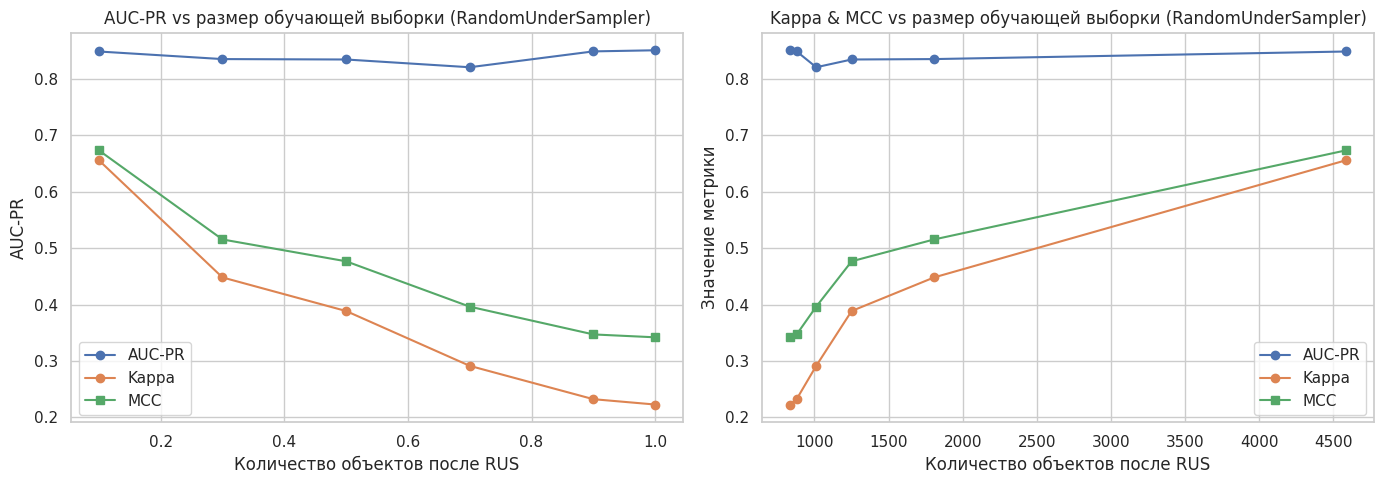

In [32]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(strategies_to_try, ap_list, marker='o', label = 'AUC-PR')
plt.plot(strategies_to_try, kappa_list, marker='o', label="Kappa")
plt.plot(strategies_to_try, mcc_list,   marker='s', label="MCC")
plt.xlabel("Количество объектов после RUS")
plt.ylabel("AUC-PR")
plt.title("AUC-PR vs размер обучающей выборки (RandomUnderSampler)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(size, ap_list, marker='o', label = 'AUC-PR')
plt.plot(size, kappa_list, marker='o', label="Kappa")
plt.plot(size, mcc_list,   marker='s', label="MCC")
plt.xlabel("Количество объектов после RUS")
plt.ylabel("Значение метрики")
plt.title("Kappa & MCC vs размер обучающей выборки (RandomUnderSampler)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Даже такой наивный подход может дать относительно неплохие результаты и улучшить наши метрики. Тем не менее, сейчас мы никак не используем информацию о распределении объектов в выборке. Оказывается, что даже относительно простые эвристические правила могут заметно поднять нам качество - например, мы можем при отбрасывании использовать близость отдельных объектов мажорного класса к минорному и отбрасывать самые близкие. Протестируйте алгоритм [Near-Miss](https://www.site.uottawa.ca/~nat/Workshop2003/jzhang.pdf) на наших данных и постройте графики, аналогичные предыдущему пункту (также добавьте график с зависимостью качества от числа соседей).

In [101]:
from imblearn.under_sampling import NearMiss

strategies_to_try = [1, 0.9, 0.7, 0.5, 0.3]
size_nm, ap_list_nm, kappa_list_nm, mcc_list_nm = [], [], [], []
num_of_neighbors = [2, 3, 5, 10]
results_nm = []

for s in tqdm(strategies_to_try):
  for n in tqdm(num_of_neighbors):
      nm = NearMiss(sampling_strategy=s, n_neighbors=n)
      X_res, y_res = nm.fit_resample(X_train, y_train)
      model = CatBoostClassifier(iterations=250, random_seed=42, verbose=0)
      model.fit(X_res, y_res, eval_set=(X_val, y_val))

      y_val_proba = model.predict_proba(X_val)[:, 1]

      ap = average_precision_score(y_val, y_val_proba)
      kappa  = cks(y_val, (y_val_proba >= 0.5).astype(int))
      mcc_score    = mcc(y_val, (y_val_proba >= 0.5).astype(int))

      size_nm.append(len(y_res))
      ap_list_nm.append(ap)
      kappa_list_nm.append(kappa)
      mcc_list_nm.append(mcc_score)

      results_nm.append({
          "proportion"        : f"1:{int(1/s)}" if s != 1 else "1:1",
          "n_after_sampling"  : len(y_res),
          "auc_pr"            : ap,
          "kappa"             : kappa,
          "mcc"               : mcc_score,
          "n_neighbors"       : n
      })

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [102]:
results_nm = pd.DataFrame(results_nm)
mask = results_nm.n_neighbors == 5

In [103]:
strategies_to_try

[1, 0.9, 0.7, 0.5, 0.3]

In [104]:
np.unique(size_nm)

array([ 834,  880, 1012, 1251, 1807])

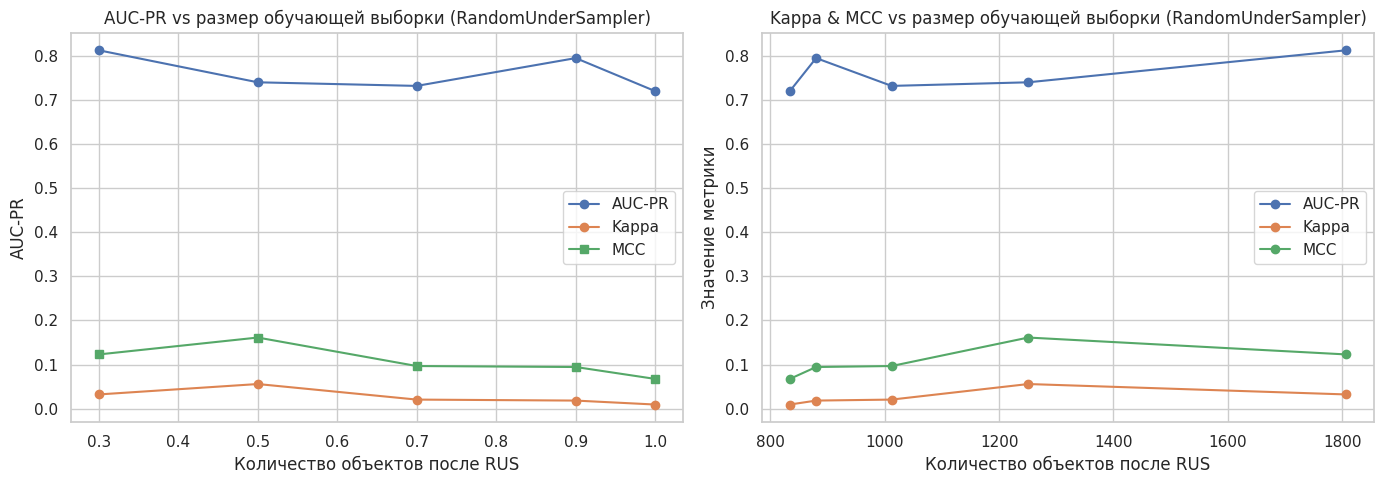

In [105]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(strategies_to_try, pd.DataFrame(ap_list_nm)[mask], marker='o', label = 'AUC-PR')
plt.plot(strategies_to_try, pd.DataFrame(kappa_list_nm)[mask], marker='o', label="Kappa")
plt.plot(strategies_to_try, pd.DataFrame(mcc_list_nm)[mask], marker='s', label="MCC")
plt.xlabel("Количество объектов после RUS")
plt.ylabel("AUC-PR")
plt.title("AUC-PR vs размер обучающей выборки (RandomUnderSampler)")
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(np.unique(size_nm), pd.DataFrame(ap_list_nm)[mask], marker='o', label = 'AUC-PR')
plt.plot(np.unique(size_nm), pd.DataFrame(kappa_list_nm)[mask], marker='o', label="Kappa")
plt.plot(np.unique(size_nm), pd.DataFrame(mcc_list_nm)[mask], marker='o', label="MCC")
plt.xlabel("Количество объектов после RUS")
plt.ylabel("Значение метрики")
plt.title("Kappa & MCC vs размер обучающей выборки (RandomUnderSampler)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Бонус (1 балл)**. imblearn также предлагает много различных методов для андерсэмплинга. Выберите что-нибудь еще из предлагаемого на свой вкус, опишите идею метода и протестируйте его.


In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [34]:
from imblearn.under_sampling import ClusterCentroids
cc = ClusterCentroids(random_state=42)
X_train_cc, y_train_cc = cc.fit_resample(X_train_scaled, y_train)

model_bonus = CatBoostClassifier(iterations=250, random_seed=42, verbose=50)
model_bonus.fit(X_train_cc, y_train_cc, eval_set=(X_val_scaled, y_val), verbose=False)
y_test_pred_cc = model_bonus.predict_proba(X_test_scaled)[:,1]

print_stats(y_test,y_test_pred_cc)

AUC PR (average_precision_score): 0.6113
AUC PR (auc from PR curve):        0.6070
Kappa Score:                        0.0030
MCC:                                0.0333


ClusterCentroids часто работает плохо, если данные не разделяются линейно или слишком сложные границы.

In [50]:
from imblearn.under_sampling import OneSidedSelection
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier

scaler = StandardScaler()
X_train_scaled_small = scaler.fit_transform(X_train[:20000])
y_train_small = y_train[:20000]
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# OneSidedSelection
oss = OneSidedSelection(random_state=42)
X_oss, y_oss = oss.fit_resample(X_train_scaled_small, y_train_small)

# CatBoost ускоренный
model_oss = CatBoostClassifier(
    iterations=100,
    # learning_rate=0.1,
    leaf_estimation_iterations=1,
    random_seed=42,
    logging_level='Silent',
    use_best_model=False
)
model_oss.fit(X_oss, y_oss, eval_set=(X_val_scaled, y_val))

# Предсказания
y_test_pred_oss = model_oss.predict_proba(X_test_scaled)[:, 1]
print_stats(y_test, y_test_pred_oss)


AUC PR (average_precision_score): 0.6543
AUC PR (auc from PR curve):        0.6516
Kappa Score:                        0.4826
MCC:                                0.5639


# Часть 2. Поиск аномалий.

Как вы могли заметить, методы балансировки выборок очень часто могут привести к не самым лучшим результатам из-за того, что они по сути искажают информацию о реальном распределении данных - в реальности обычно требуется долгий подбор в принципе работоспособных для задачи методов и их аккуратная настройка.

Теперь давайте попробуем слегка сменить постановку задачи и переключиться на задачу "одноклассовой" классификации, то есть - поиска *аномалий* в выборке. В общем-то, это вполне согласуется с нашей областью работы - мы действительно можем назвать мошеннические транзакции аномальньми (как интуитивно, так и на основании наблюдаемой балансировки данных).

Стоит отметить, что методы обнаружения аномалий чаще всего относятся к классу методов обучения без учителя. Это дает некоторый положительный эффект - нам не обязательно нужно тратить время на разметку данных (тем не менее, для контроля качества какую-то часть разметить все-таки придется). Впрочем, чаще всего перфоманс таких методов оказывается заметно хуже, чем у честного обучения с учителем (если мы можем себе его позволить).



**Задание 4. (3 балла).** На занятиях вы разбирали схожий с Random Forest подход для детекции аномалий без известной разметки данных, называемый Isolation Forest. Напомним суть: на этапе обучения мы создаем ансамбль из решающих деревьев, в котором признак и порог на каждую вершину подбираются случайно. Затем мы считаем для объектов оценку аномальности через длину пути до соответствующего листа в каждом дереве.

В данном задании вам предлагается реализовать модификацию данного алгоритма, известную как Extended Isolation Forest. В ней мы на каждом шаге будем определять не порог для признака, а полноценную случайную гиперплоскость, разбивающую выборку на 2 части. С детальным описанием вы можете ознакомиться [здесь](https://arxiv.org/pdf/1811.02141.pdf).

Ниже приведен шаблон кода. Постарайтесь работать в его рамках (минорные изменения вполне допустимы, главное не переворачивайте всю структуру с ног на голову).

**NB**: будем считать, что в нашем датасете нет категориальных признаков - можете не заморачиваться с их обработкой (но в общем случае, это будет важно).

**Советы**:
 - Численные признаки лучше предобработать надлежащим образом.
 - Возможно, вам поможет выбрасывание некоторых признаков.
 - Внимательно следите за знаками.
 - Не игнорируйте документирующие строки.
 - Вероятнее всего, вы не сможете приблизиться по качеству к supervised-решениям. Если у вас не получается это сделать (но вы уверены в своей правоте), не стоит тратить слишком много времени на поиск ошибок.
- При желании, можете вынести этот код в отдельный файл и приложить его к ноутбуку. Он довольно громоздкий и в ноутбуке такое плохо читается.


**Бонусы (каждый по 0.5)**:
- Сделайте ваш EIF параллельным (`multiprocessing`, `joblib`).
- Добавьте возможность откатиться к дефолтному варианту Isolation Forest. (порассуждайте, как можно реализовать это в данной модели?):


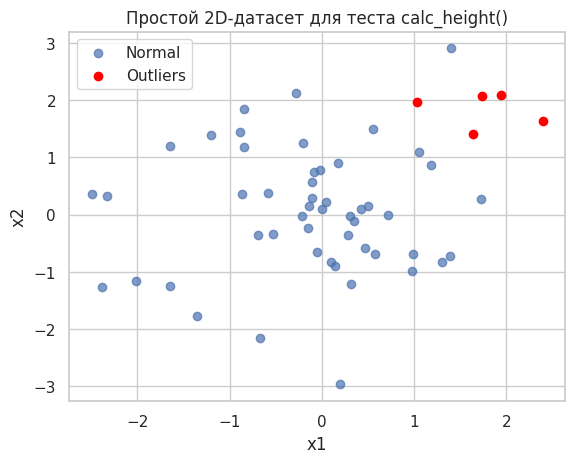

In [60]:
# проверочка

XX_norm = np.random.normal(loc = 0, scale = 1, size = (50,2))
XX_outl = np.random.normal(loc = 2, scale = 0.5, size = (5, 2))
XX = np.concatenate([XX_norm, XX_outl], axis = 0)
yy = np.array([0]*50 + [1]*5)


plt.scatter(XX_norm[:, 0], XX_norm[:, 1], label="Normal", alpha=0.7)
plt.scatter(XX_outl[:, 0], XX_outl[:, 1], label="Outliers", color='red')
plt.legend()
plt.title("Простой 2D-датасет для теста calc_height()")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

In [61]:
calc_height(XX, 2, left)

NameError: name 'left' is not defined

In [ ]:
def calc_height(X, depth, node, scores):
    if node.kind == "external":
        if node.size <= 1:
            scores[:] = depth
        else:
            scores[:] = depth + c_factor(node.size)
        return
    left = (X @ node.w) < node.b
    calc_height(X[left], depth + 1, node.left, scores[left])
    calc_height(X[~left], depth + 1, node.right, scores[~left])


In [13]:
def c_factor(n):
    """
    Computes average path length for an unsuccessful search in a binary search tree.
    Params:
        n: int - number of data points for BST
    """
    return 2*(np.log(n-1)+ 0.5772156649)-2*(n-1)/n

def calc_height(X, depth, node, scores):
    """
    Calculates anomaly scores for sample in a recursive manner.
    Params:
        X: np.array - current sample, available to node

        depth: int - path length up to current node

        node: Node - current tree node

    Returns:
        scores: int, float or np.array - anomaly scores for sample
    """
    if node.kind == "external":
        if node.size <= 1:
            scores[:] = depth
        else:
            scores[:] = depth + c_factor(node.size)
        return
    left = (X @ node.w) < node.b
    calc_height(X[left], depth + 1, node.left, scores[left])
    calc_height(X[~left], depth + 1, node.right, scores[~left])

class Node(object):
    """
    A single node object for each tree. Contains information on height, current data,
    splitting hyperplane and children nodes.

    Attributes:
        X: np.array - data available to current node
        size: int - length of available data

        depth: int - depth of node

        left: Node - left child
        right: Node - right child

        kind: str - either "internal" or "external", indicates the type of current node

        w: np.array - normal vector for the splitting hyperplane
        b: float - intercept term for the splitting hyperplane
    """
    def __init__(self, X, depth, left, right, kind, w, b):
        """
        Node(h, left, right, kind, w, b)
        Represents the node object.

        Params:
            X: np.array - data available to current node
            depth: int - depth of node

            left: Node - left child
            right: Node - right child

            kind: str - either "internal" or "external", indicates the type of current node

            w: np.array - normal vector for the splitting hyperplane
            b: float - intercept term for the splitting hyperplane

        """
        self.size = len(X)

        self.depth = depth

        self.left = left
        self.right = right

        self.kind = kind

        self.w = w
        self.b = b

    def __repr__(self):
        """
        For convenience only.
        """
        return f"Node(size={self.size}, depth={self.depth}, kind={self.kind})"

class RandomizedTree(object):
    """
    Single randomized tree object. Stores root and its depth (tree is built recursively).
    Attributes:
        depth: int - current tree depth

        max_depth: int - maximum tree depth

        root: Node - root node

        internal_count: int - number of internal nodes

        external_count: int - number of external nodes

    """
    def __init__(self, X, max_depth):
        """
        Single randomized tree object. Stores root and its depth (tree is built recursively).
        Params:
            X: np.array - train sample
            max_depth: int - maximum tree depth

        """
        self.depth = 0
        self.max_depth = max_depth

        self.internal_count = 0
        self.external_count = 0

        self.root = self.grow(X, 0)

    def __repr__(self):
        """
        For convenience only.
        """

        return f"RandomizedTree(depth={self.depth}, max_depth={self.max_depth}, n_internal={self.internal_count}, n_external={self.external_count})"



    def grow(self, X, depth):
        """
        Grow tree in a recursive manner.
        Params:
            X: np.array - available train sample

            depth: int - current tree depth

        Returns:
            node: Node - a trained node with separating hyperplane data.
                         Node provides access to children if necessary (these are built recursively)
        """
        if depth >= self.max_depth or len(X) <= 1:
            self.external_count+=1
            self.depth = max(self.depth, depth)
            return Node(X, depth, left = None, right = None, kind = 'external', w=None, b=None)
        self.internal_count += 1
        mins = X.min(axis=0)
        maxs = X.max(axis=0)
        zero_idxs = np.random.choice(self.dim, self.dim - self.exlevel - 1, replace=False)

        i = 0
        while True:
            n = np.random.randn(self.dim)
            n[zero_idxs] = 0
            p = np.random.uniform((X @ n).min(), (X @ n).max())
            w = (X @ n) <= p
            if w.any() and (~w).any():
                break
            i += 1
            if i > 100:
                self.external_count += 1
                return Node(X, depth, left=None, right=None, kind='external', w=None, b=None)

        left_node  = self.grow(X[w],  depth + 1)
        right_node = self.grow(X[~w], depth + 1)

        return Node(X, depth, left_node, right_node, kind='internal', w=n, b=-p)

    def score_samples(self, X):
        """
        Calculate anomaly scores for given data. You may utilize outer function `calc_height`.
        Params:
            X: np.array - data to be evaluated

        Returns:
            scores: np.array - estimated anomaly scores
        """
        path_lengths = calc_height(X, depth=0, node=self.root)
        c_n = c_factor(self.root.size)
        scores = 2 ** (-path_lengths / c_n)
        return scores


class ExtendedIsolationForest(object):
    """
    Extended Isolation Forest object. Stores training data and trained randomized trees.
    Attributes:
        n_trees: int - number of Randomized Trees

        max_depth: int - maximum depth of each tree

        subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

        trees: list - container for trained trees

        contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

    """

    def __init__(self, n_trees, subsample_rate, max_depth=None, contamination=0.01):
        """
        Extended Isolation Forest object. Stores training data and trained randomized trees.
        Params:
            n_trees: int - number of Randomized Trees

            subsample_rate: float - draw `subsample_rate * X.shape[0]` samples for each tree

            max_depth: int or None - maximum depth of each tree. Defaults to ceil(log_2(subsample_size)) if not provided

            contamination: float - estimated fraction of anomaly samples in data. Used for thresholding

        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.subsample_rate = subsample_rate
        self.trees = []
        self.dim = X.shape[1]
        self.contamination = contamination
        self.is_fit = False

    def __repr__(self):
        """For convenience only."""

        return f"ExtendedIsolationForest(n_trees={self.n_trees}, max_depth={self.max_depth}, subsample_rate={self.subsample_rate}, contamination={self.contamination}, is_fit={self.is_fit})"

    def fit(self, X):
        """
        Fit EIF to new data.
        Params:
            X: np.array - 2d array of samples
        """
        if self.max_depth == None:
            self.max_depth = np.ceil(np.log2(int(self.subsample_rate * X.shape[0])))

        for i in range(self.n_trees):
            n_samples = int(self.subsample_rate * X.shape[0])
            idx = np.random.choice(X.shape[0], size=n_samples, replace=False)
            X_sub = X[idx]
            self.trees.append(RandomizedTree(X_sub, self.max_depth))
        self.is_fit = True


    def score_samples(self, X):
        """
        Estimate (normalized) anomaly score for each given sample
        Params:
            X: np.array - new samples

        Returns:
            scores: np.array - anomaly scores (larger value means higher probability of a sample being an outlier)
        """
        if not self.is_fit:
            raise NotImplementedError

        c = c_factor(len(X))

        hs = np.array([tree.score_samples(X) for tree in self.trees])
        scores = 2 ** (-np.mean(hs, axis=0) / c)

        return scores


    def predict(self, X):
        """
        Predict if given samples are outliers.
        Params:
            X: np.array - new samples

        Returns:
            labels: np.array - anomaly labels (1 for outliers, 0 for inliers)
        """
        labels = np.zeros(len(X))
        scores = self.score_samples(X)
        constraint = scores >= self.contamination
        labels[constraint] = 1

        return labels


In [14]:
# import numpy as np

# np.random.seed(42)

# # 100 нормальных точек
# X_normal = np.random.normal(0, 1, (100, 2))

# # 5 выбросов
# X_outliers = np.random.uniform(low=-6, high=6, size=(5, 2))

# # Объединяем
# X = np.vstack([X_normal, X_outliers])

# # Инициализируем модель
# model = ExtendedIsolationForest(n_trees=100, subsample_rate=0.5, contamination=0.05)
# model.fit(X)

# # Получаем аномальные очки
# scores = model.score_samples(X)
# labels = model.predict(X)

AttributeError: 'RandomizedTree' object has no attribute 'dim'

**Задание 5. (1 балл).** Протестируйте вашу реализацию EIF и подберите оптимальные гиперпараметры (наш метод не использует разметку, поэтому можете попробовать делать это на обучающей выборке). Сравните ее с обычным IF из `sklearn` (желательно делать это на одних и тех же параметрах). Удалось ли сделать лучше?

In [ ]:
#your code here

Возможно, ваш алгоритм выдал большие оценки объектам с негативной разметкой. Постарайтесь выбрать несколько таких объектов и доступно объяснить (= с кодом и графиками), почему так вышло:

In [ ]:
#your code here

**Задание 6. (1 балл).** `sklearn` также предлагает нам и другие методы для поиска аномалий. В этом задании мы предлагаем вам сделать следующее:

Для начала попробуйте использовать методы Local Outlier Factor и One-Class SVM. Сравните результаты с IF и EIF.  

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1).fit(X_train)
y_pred_lof = lof.predict(X_test)

In [ ]:
svm = OneClassSVM(max_iter=100э).fit(X_train)
y_pred_svm = svm.fit_predict(X_test)

У вас началась депрессия из-за плохих метрик? Не беда! Сейчас давайте сделаем так: все методы, опробованные в этой части, попробуем задействовать для создания дополнительных признаков в данных. Проделайте это (не забудьте, что обучаться здесь нужно на трейне). Теперь возьмите лучшую модель из предыдущей части и обучите на новых данных. Смогли ли unsupervised-методы повысить вам качество?

In [ ]:
#your code here

**Бонус. (0.1 балла).**

При сдаче проверяющий запустит следующую клетку один раз. Если она даст положительный результат, вы получите 0.1 бонусных балла. Если она даст отрицательный результат, вы получите -0.1 бонусных балла.

Если вы хотите отказаться от сдачи данного задания, допишите "хочу" после двоеточия: `your text here`

Ниже вы можете попрактиковаться и оценить ваши силы (изменять код ячейки запрещается!)

In [115]:
import random

rng = random.SystemRandom(0)
rng.uniform(-1.0, 1.0)

0.5818314290961883